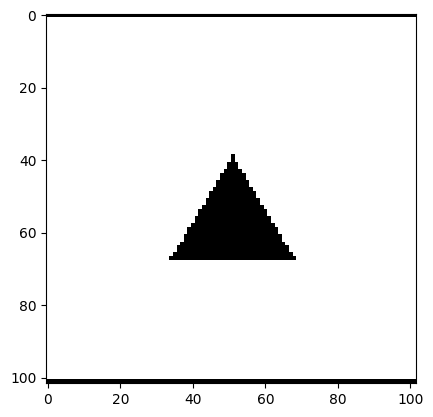

In [351]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

def add_circles(mesh, centers, radii):
    Ny, Nx = mesh.shape
    for center, radius in zip(centers, radii):
        y_center, x_center = center
        for y in range(Ny):
            for x in range(Nx):
                distance = np.sqrt((y - y_center)**2 + (x - x_center)**2)
                if distance <= radius:
                    mesh[y, x] = 0
    return mesh

def place_triangle(arr, base_len, dist_from_bottom, height):
    rows, cols = arr.shape

    y_base = rows - 1 - dist_from_bottom
    y_top = y_base - height
    
    center_x = cols // 2
    x_left = center_x - (base_len // 2)
    x_right = x_left + base_len
    
    yy, xx = np.ogrid[:rows, :cols]
    left_edge = (xx - center_x) >= -(base_len / 2) * (yy - y_top) / height
    right_edge = (xx - center_x) <= (base_len / 2) * (yy - y_top) / height
    within_height = (yy <= y_base) & (yy >= y_top)
    triangle_mask = left_edge & right_edge & within_height
    arr[triangle_mask] = 0
    
    return arr

Nx = 102
Ny = 102
domain = np.ones((Ny, Nx), dtype=int)
# domain = add_circles(domain, centers=[(30, 30), (60, 60)], radii=[10, 10])
domain = place_triangle(domain, 34, 34, 28)
domain[0, :] = 0
domain[-1, :] = 0

# domain[20:25, 20:25] = 0
dx = 0.122e-9 # nano-meter
# dx = 0.167e-9 # nano-meter

plt.figure()
plt.imshow(domain, cmap='gray')

In [352]:
from poreProcessor import thermodynamic_properties

P = 2.0e6 # Pa, pressure
T = 300.0 # K, temperature

# methane properties
Tc = 190.564 # K
Pc = 4.5992e6 # Pa
rhoc_phy = 162.66 # kg/m^3
w_phy = 0.011 # acentric factor
Mw_phy = 16.043 / 1000 # kg/mol
d_mole_phy = 3.758e-10 # m, effective diameter of methane molecule

rhoG_phy, rhoG_lu, lamb, Crho = thermodynamic_properties(P, T, Tc, Pc, w_phy, Mw_phy, d_mole_phy)
  
print(rhoG_phy, rhoG_lu, lamb, Crho)

13.428130745091918 0.2355545440759889 7.904614716131531e-10 57.00646021398789


====== Smoothing pores-1 ======
Cleaning attempt- 1
0.150247154210098


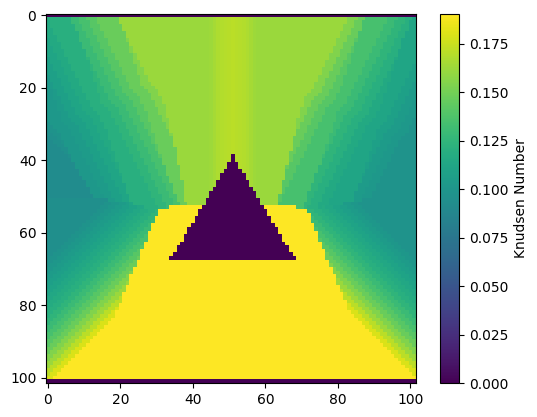

In [359]:
from poreProcessor import pore_properties_opt

kn, local_pore_size, domain, _ = pore_properties_opt(domain, lamb, dx)
print(np.mean(kn[kn!=0]))
# kn[kn!=0] = 0.15
plt.figure()
plt.imshow(kn, cmap='viridis')
plt.colorbar(label='Knudsen Number')

In [361]:
with h5py.File("binary_media.h5", "w") as f:
    f.create_dataset("binary_media", data=domain.T, dtype='i8')

with h5py.File("local_pore_size.h5", "w") as f:
    f.create_dataset("local_pore_size", data=local_pore_size.T, dtype='float64')

with h5py.File("Kn.h5", "w") as f:
    f.create_dataset("Kn", data=kn.T, dtype='float64')

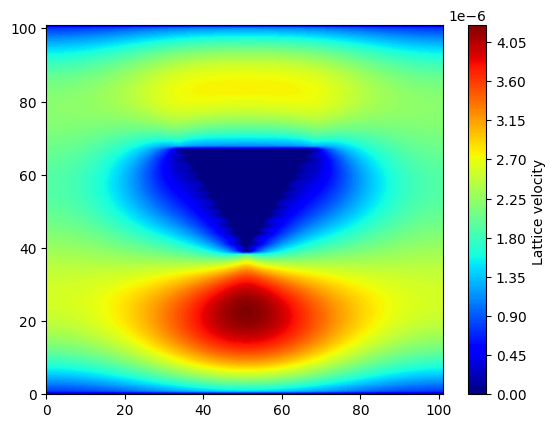

In [370]:
with h5py.File('channel.h5', 'r') as hf:
    keys = list(hf.keys())
    c_key_idx = np.sort([int(k.split('.')[-1]) for k in keys if 'velocity_x' in k])

    plot_var = hf['velocity_x.'+str(c_key_idx[-1])][()].T
    plt.figure()
    plt.contourf(plot_var, cmap='jet', levels=200)
    plt.colorbar(label='Lattice velocity ')

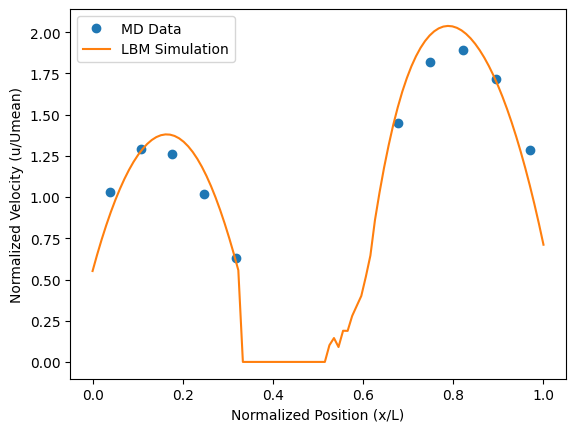

In [ ]:
# Molecular Dynamics data yoinked from DOI:10.1088/0169-5983/45/3/034501
md_x = np.array([0.0377777777777779, 0.106666666666666, 0.175555555555555, 0.246666666666666, 0.317777777777777, 0.677777777777777, 0.748888888888888, 0.822222222222222, 0.895555555555555, 0.97111111111111])
md_ux = np.array([1.03333333333333, 1.29333333333333, 1.26, 1.02, 0.633333333333328, 1.44666666666666, 1.82, 1.89333333333333, 1.71333333333333, 1.28666666666666])

lbm_ux = plot_var[::-1, 45]
lbm_ux = lbm_ux[1:-1]
lbm_ux = lbm_ux / np.mean(lbm_ux)
lbm_x = np.linspace(0, 1, len(lbm_ux))

plt.figure()
plt.plot(md_x, md_ux, 'o', label='MD Data')
plt.plot(lbm_x, lbm_ux, label='LBM Simulation')
plt.xlabel('Normalized Position (x/L)')
plt.ylabel('Normalized Velocity (u/Umean)')
plt.legend()
plt.show()
